World Bank Economic Data ( Cleaning and Analysis)
Author : Aiman Ishaq
Data Source : World Bank Open Data
Indicators Used:
   GDP per capita (current USD)
   Inflation, consumer prices(annual%)
   Unemployment, total(% of total labour force)
Objective
The World Bank publishes country level economic indicators in wide format (one column per year), with mixed aggregate regions and real countries in the same file. This notebook:
1. Cleans and reshapes three indicator files into a single tidy long format Dataset
2. Filters to real countries only (removes regional aggregates like WLD, ECA)
3. Engineers Pakistan's features for downstream analysis
4. Explores Pakistan's economic trajectory VS the South Asia regional average

1. imports

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from scipy import stats
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
plt.rcParams.update({'figure.dpi': 130,'axes.spines.top': False, 'axes.spines.right': False,'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize' : 11})


2. Load Data
World Bank CSVs have 4 metadata rows at the top (skip=4 skips them)

In [3]:
gdp = pd.read_csv('GDP.csv', skiprows=4)
inflation = pd.read_csv('inflation.csv', skiprows=4)
unemployment = pd.read_csv('unemployment.csv', skiprows=4)

In [4]:
print('GDP shape:', gdp.shape)
print('Inflation shape:', inflation.shape)
print('Unemployment shape:', unemployment.shape)

GDP shape: (266, 71)
Inflation shape: (266, 71)
Unemployment shape: (266, 71)


3. Clean : Drop junk Columns
Each World Bank file comes with unnamed trailing columns and two redundant indicator columns(Indicator Name, Indicator Code). we strip these first.

In [5]:
def drop_junk(df):
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df = df.drop(columns=['Indicator Name', 'Indicator Code'], errors='ignore')
    return df
gdp = drop_junk(gdp)
inflation = drop_junk(inflation)
unemployment = drop_junk(unemployment)
print("columns after dropping junk:", gdp.columns.tolist()[:8], '...')

columns after dropping junk: ['Country Name', 'Country Code', '1960', '1961', '1962', '1963', '1964', '1965'] ...


4. Filter: remove Regional Aggregates
World Bank files mix real countries (3 letter ISO codes like PAK,USA) with regional aggregates (WLD, ECA, SSA, etc.). we keep only real countries using two rules:
   country Code matches the 3 capital letter ISO pattern
   Explicitly exclude known aggregate codes that happen to match the pattern


In [6]:
NON_COUNTRY_CODES = [
    'WLD', 'LMY', 'UMC', 'LMC', 'LIC', 'HIC', 'MIC', 'EAP', 'ECA', 'LAC',
    'MNA', 'SAS', 'SSA', 'NAC', 'OED', 'EMU',
    'AFE', 'AFW', 'ARB', 'CEB', 'CSS', 'EAR', 'EAS', 'ECS', 'EUU', 'FCS',
    'HPC', 'IBD', 'IBT', 'IDA', 'IDB', 'IDX', 'INX', 'LCN', 'LDC', 'LTE',
    'MEA', 'OSS', 'PRE', 'PSS', 'PST', 'SSF', 'SST', 'TEA', 'TEC', 'TLA',
    'TMN', 'TSA', 'TSS'
]
def filter_countries(df):
    real_countries = df['Country Code'].str.match(r'^[A-Z]{3}$') 
    df = df[real_countries & ~df['Country Code'].isin(NON_COUNTRY_CODES)]
    return df.reset_index(drop=True)
gdp = filter_countries(gdp)
inflation = filter_countries(inflation)
unemployment = filter_countries(unemployment)
print(f"Countries remaining:{gdp.shape[0]}")

Countries remaining:217


5. Reshape: Wide to Long
World Bank data is in wide format (one column per year)
For analysis we need long format : one row per combination
pd.melt() handles this reshape. we also cast Year to integer for filtering and plotting

In [7]:
def wide_to_long(df, value_name):
    year_cols = [c for c in df.columns if re.match(r'^\d{4}$', str(c))]
    df_long = pd.melt(df, id_vars=['Country Name', 'Country Code'], value_vars=year_cols, var_name='Year', value_name=value_name)
    df_long['Year'] = df_long['Year'].astype(int)
    return df_long
gdp_long = wide_to_long(gdp, 'gdp_per_capita')
inflation_long = wide_to_long(inflation, 'inflation_pct')
unemployment_long = wide_to_long(unemployment, 'unemployment_pct')
print('Long GDP shape:', gdp_long.shape)
gdp_long.head()


Long GDP shape: (14322, 4)


,Country Name,Country Code,Year,gdp_per_capita
0,Aruba,ABW,1960,NaN
1,Afghanistan,AFG,1960,NaN
2,Angola,AGO,1960,NaN
3,Albania,ALB,1960,NaN
4,Andorra,AND,1960,NaN


6. Merge into a Single Dataset
we join all three indicator on Country Code + Year.
A left join on GDP preserves all country year combinations from the GDP file ; missing values in inflation and unemployment are expected

In [8]:
df = gdp_long.merge(inflation_long[['Country Code','Year','inflation_pct']], on=[ 'Country Code', 'Year'], how='left')
df = df.merge(unemployment_long[['Country Code','Year','unemployment_pct']], on=[ 'Country Code', 'Year'], how='left')
print('Merged shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())

Merged shape: (14322, 6)

Missing values:
Country Name           0
Country Code           0
Year                   0
gdp_per_capita      2753
inflation_pct       5351
unemployment_pct    7791
dtype: int64


7. Filter to 1990 Onwards
Coverage before 1990 is sparse , many countries didn't report consistently during the cold war era. 
Filtering to 1990+ gives us a denser, more reliable dataset while still covering 30+ years of economic history including the Asia financial crisis, 2008 GFC, and COVID-19.

In [9]:
# Check coverage by year
coverage = df.groupby('Year')['gdp_per_capita'].count() 
print('Data coverage (countries reporting GDP per year):')
print(coverage.tail(10))
df = df[df['Year'] >= 1990].copy()
# Flag rows with missing values 
df_complete = df.dropna(subset=['gdp_per_capita', 'inflation_pct', 'unemployment_pct']).copy()
print(f"\nRows after 1990 filter: {len(df):,}")
print(f"Complete cases: {len(df_complete):,}")

Data coverage (countries reporting GDP per year):
Year
2016    211
2017    211
2018    211
2019    211
2020    210
2021    210
2022    209
2023    203
2024    192
2025      0
Name: gdp_per_capita, dtype: int64

Rows after 1990 filter: 7,812
Complete cases: 5,522


In [10]:

total_rows = len(df)
missing_inf_pct = df['inflation_pct'].isna().sum() / total_rows * 100
missing_unemp_pct = df['unemployment_pct'].isna().sum() / total_rows * 100

print(f"Post-1990 missing: inflation {missing_inf_pct:.1f}%, unemployment {missing_unemp_pct:.1f}%")

Post-1990 missing: inflation 23.0%, unemployment 16.4%


8. Standardise Country Names

In [11]:
name_fixes = {
    "Bahamas, The": "The Bahamas",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Egypt, Arab Rep.": "Egypt",
    "Iran, Islamic Rep.": "Iran",
    "Korea, Rep.": "South Korea",
    "Kyrgyz Republic": "Kyrgyzstan",
    "Lao PDR": "Laos",
    "Russian Federation": "Russia",
    "Syrian Arab Republic": "Syria",
    "Venezuela, RB": "Venezuela",
    "Yemen, Rep.": "Yemen"
}
df['Country Name'] = df['Country Name'].replace(name_fixes)
df_complete['Country Name'] = df_complete['Country Name'].replace(name_fixes)
print('Name standardisation applied')


Name standardisation applied


9. Feature Engineering
Two derived columns are added:
  . gdp_category
         World Bank income thresholds(USD per capita)
         purpose is to Enable Group comparisons
  . decade
         Year floored to decade
         purpose is trend aggregation

Note: an economic_stress_index (mean of inflation % and unemployment %) was
originally engineered here but has been removed. Unemployment is excluded
from the final analysis due to data quality concerns, which left the stress
index unused downstream, so it was dropped rather than kept as dead weight.

In [12]:
# equal weight mean; both indicators are already in % units so scale is comparable.
# Rows where one indicator is missing still get a partial score (skipna=True)

def assign_income_category(row):
    """Map GDP per capita to WB income tier using thresholds from that era."""
    y = row['Year']
    g = row['gdp_per_capita']
    if pd.isna(g):
        return np.nan
    # Approximate World Bank thresholds by year (current USD)
    if y <= 1994:
        low, lm, um = 545, 2195, 6000
    elif y <= 1999:
        low, lm, um = 675, 2695, 8355
    elif y <= 2004:
        low, lm, um = 755, 2995, 9265
    elif y <= 2009:
        low, lm, um = 875, 3465, 10725
    elif y <= 2014:
        low, lm, um = 1005, 3975, 12275
    elif y <= 2019:
        low, lm, um = 1045, 4125, 12735
    else:
        low, lm, um = 1085, 4255, 13205
    
    if g <= low:
        return 'Low Income'
    elif g <= lm:
        return 'Lower-Middle Income'
    elif g <= um:
        return 'Upper-Middle Income'
    else:
        return 'High Income'

df['gdp_category'] = df.apply(assign_income_category, axis=1)
df['decade'] = ((df['Year'] // 10)*10).astype(str) + 's'

if 'df_complete' in globals():
    df_complete['gdp_category'] = df_complete.apply(assign_income_category, axis=1)

print(df[['Country Name', 'Year', 'gdp_per_capita', 'gdp_category']].head(10))

              Country Name  Year  gdp_per_capita         gdp_category
6510                 Aruba  1990    12187.536361          High Income
6511           Afghanistan  1990             NaN                  NaN
6512                Angola  1990      965.866840  Lower-Middle Income
6513               Albania  1990      617.230436  Lower-Middle Income
6514               Andorra  1990    19563.657472          High Income
6515  United Arab Emirates  1990    26709.993440          High Income
6516             Argentina  1990     4315.334031  Upper-Middle Income
6517               Armenia  1990      635.355328  Lower-Middle Income
6518        American Samoa  1990             NaN                  NaN
6519   Antigua and Barbuda  1990     7590.754424          High Income


10. Pakistan analysis
Pakistan is one of the world's most populous lower middle income economies. Here we examine:
  its GDP per capita trend vs South Asia regional average
  its worst inflation years

Unemployment is not analysed here: coverage is too sparse post-1990
(missing in 16.4% of rows, worse for Pakistan specifically) to support a
reliable trend, which is also why it was dropped from the engineered
stress index above.

In [13]:
south_asia_codes = ['IND','BGD','LKA','NPL','BTN', 'AFG']
# MDV (Maldives) excluded: tourism microstate, population ~500k, 2024 GDP per
# capita of $13,379 is several times every other country in the comparison
# set and pulls the regional mean up sharply. Excluding it makes the
# "South Asia average" reflect the countries Pakistan is actually being
# benchmarked against (India, Bangladesh, Sri Lanka, Nepal, Bhutan, Afghanistan).
# PAK excluded intentionally from south_asia_codes — comparing Pakistan against peers, not itself

pakistan = df[df['Country Code'] == 'PAK'].copy()
south_asia = df[df['Country Code'].isin(south_asia_codes)].copy()

# NO forward-fill. Only average actual reported values per year.
sa_avg = (
    south_asia
    .dropna(subset=['gdp_per_capita'])
    .groupby('Year')['gdp_per_capita']
    .mean()
    .rename('South Asia Avg')
)

print("Countries reporting GDP in 2024:", 
      south_asia[(south_asia['Year']==2024) & south_asia['gdp_per_capita'].notna()].shape[0])

worst_inflation = pakistan.loc[pakistan['inflation_pct'].idxmax()]
print(f"\nWorst inflation year: {int(worst_inflation['Year'])} at {worst_inflation['inflation_pct']:.1f}%")

print(f"\nPakistan vs South Asia average - last 10 years:")
comparison = pakistan.set_index('Year')['gdp_per_capita'].to_frame().join(sa_avg)
print(comparison.tail(10))

# Growth volatility caveat: figures are in current USD, and PKR has depreciated
# substantially over this period, so part of Pakistan's year-over-year USD
# volatility reflects exchange rate movement, not only real output swings.
print("\nNote: GDP figures are in current USD. Pakistan's PKR has depreciated")
print("substantially over this period, so year-over-year USD volatility partly")
print("reflects exchange rate movement, not only real output swings.")

pak_growth = pakistan.set_index('Year')['gdp_per_capita'].dropna().pct_change().dropna() * 100
sa_growth = sa_avg.pct_change().dropna() * 100
print(f"\nPakistan GDP growth std dev: {pak_growth.std():.2f}%")
print(f"South Asia avg GDP growth std dev: {sa_growth.std():.2f}%")

Countries reporting GDP in 2024: 4

Worst inflation year: 2023 at 30.8%

Pakistan vs South Asia average - last 10 years:
      gdp_per_capita  South Asia Avg
Year                                
2016     1424.691612     2009.605394
2017     1519.234595     2192.519458
2018     1569.338146     2226.799844
2019     1390.416910     2254.966776
2020     1278.397352     2143.360998
2021     1455.319224     2316.547497
2022     1538.322813     2310.178370
2023     1360.324178     2417.907004
2024     1478.772780     2812.757961
2025             NaN             NaN

Note: GDP figures are in current USD. Pakistan's PKR has depreciated
substantially over this period, so year-over-year USD volatility partly
reflects exchange rate movement, not only real output swings.

Pakistan GDP growth std dev: 11.30%
South Asia avg GDP growth std dev: 7.33%


11. Visualisations
    11.1. Pakistan GDP per CApita vs South Asia Average

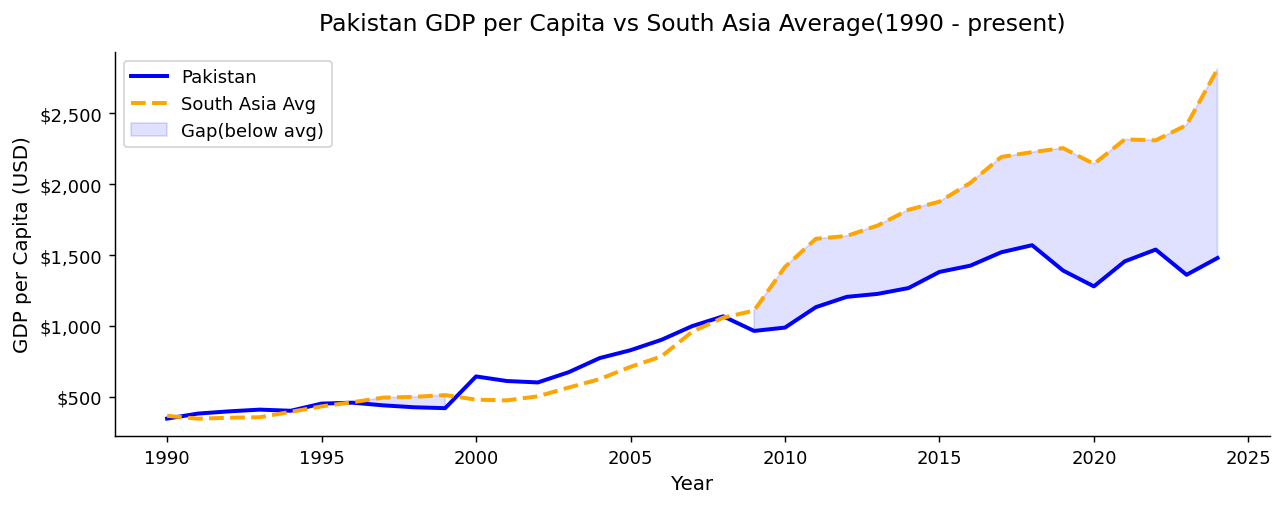

In [14]:
fig, ax = plt.subplots(figsize=(10,4))

pak_gdp = pakistan.set_index('Year')['gdp_per_capita'].dropna()
ax.plot(pak_gdp.index, pak_gdp.values, color='blue', linewidth=2.2, label='Pakistan')
ax.plot(sa_avg.index, sa_avg.values, color='orange', linewidth=2.2, linestyle='--', label='South Asia Avg')

ax.fill_between(pak_gdp.index, pak_gdp.values, sa_avg.reindex(pak_gdp.index), where=(pak_gdp.values < sa_avg.reindex(pak_gdp.index).values), color='blue', alpha=0.12, label ='Gap(below avg)')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Pakistan GDP per Capita vs South Asia Average(1990 - present)', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('GDP per Capita (USD)')
ax.legend()
plt.tight_layout()
plt.show()

11.2. Pakistan inflation History

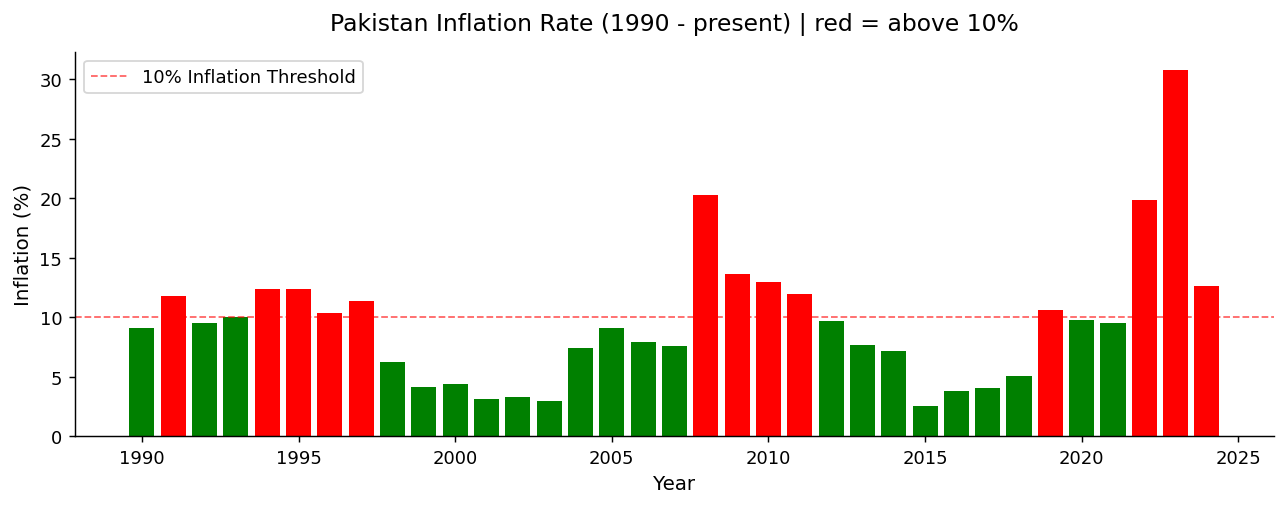

In [15]:
fig, ax = plt.subplots(figsize=(10,4))
pak_inf = pakistan[['Year', 'inflation_pct']].dropna()
colors = ['red' if v > 10 else 'green' for v in pak_inf['inflation_pct']]
ax.bar(pak_inf['Year'], pak_inf['inflation_pct'], color=colors, width=0.8)
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='10% Inflation Threshold', alpha=0.6)
ax.set_title('Pakistan Inflation Rate (1990 - present) | red = above 10%', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Inflation (%)')
ax.legend()
plt.tight_layout()  
plt.show()

11.3. South Asia GDP per capita Comparison(latest year)

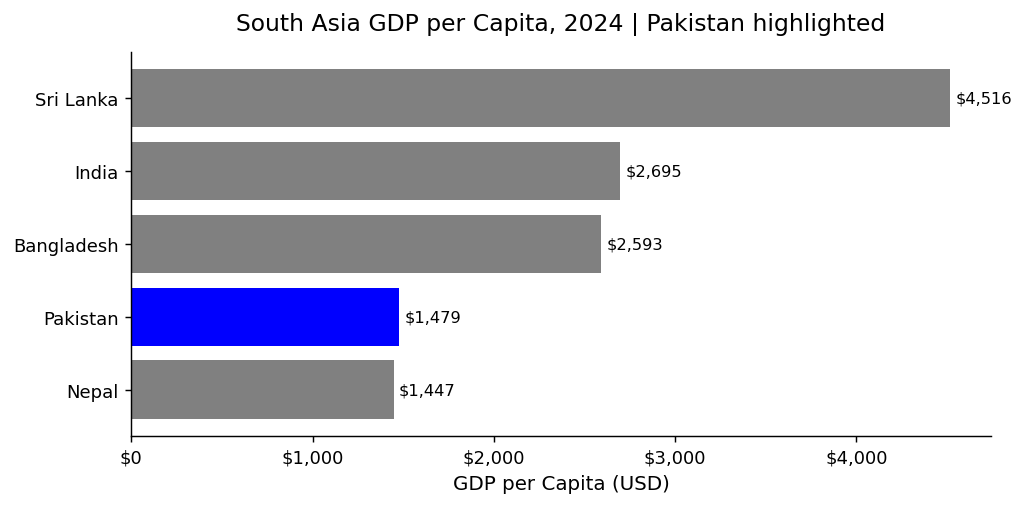

In [16]:
latest_year = south_asia.dropna(subset=['gdp_per_capita'])['Year'].max()
pak_latest = pakistan[pakistan['Year'] == latest_year][['Country Name', 'Country Code', 'gdp_per_capita']]
sa_latest = pd.concat([south_asia[south_asia['Year'] == latest_year], pak_latest]).dropna(subset=['gdp_per_capita']).sort_values('gdp_per_capita', ascending=True)
fig, ax = plt.subplots(figsize=(8,4))
bar_colors = ['blue' if code == 'PAK' else 'gray' for code in sa_latest['Country Code']]
bars = ax.barh(sa_latest['Country Name'], sa_latest['gdp_per_capita'], color=bar_colors)
for bar, val in zip(bars, sa_latest['gdp_per_capita']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=9)
ax.set_title(f'South Asia GDP per Capita, {latest_year} | Pakistan highlighted', pad=12)
ax.set_xlabel('GDP per Capita (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

11.4. Distribution of GDP Category by Decade

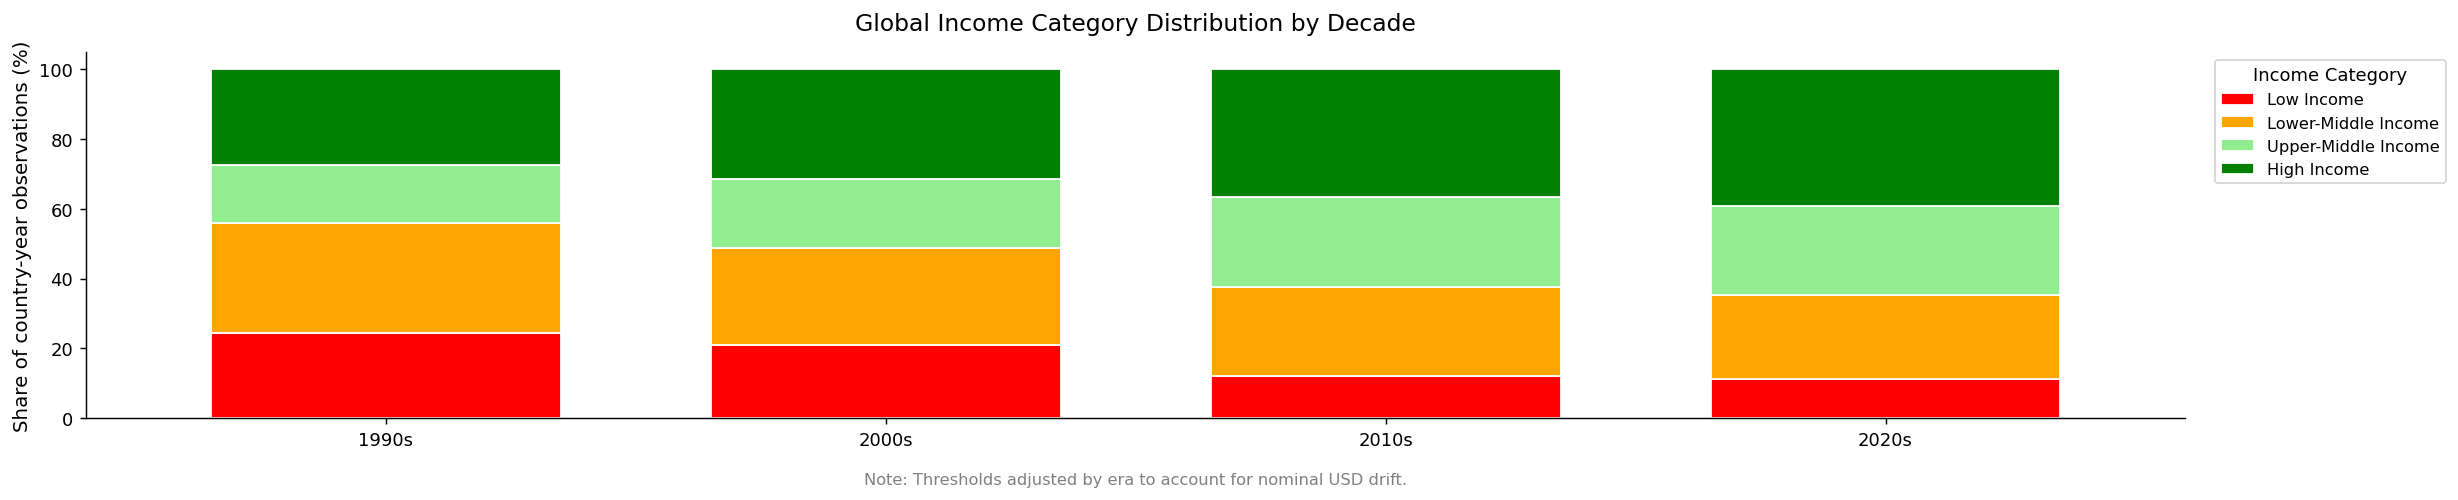

In [17]:
cat_order = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']
cat_palette = {'Low Income': 'red', 'Lower-Middle Income': 'orange', 'Upper-Middle Income': 'lightgreen', 'High Income': 'green'}
decade_cat = (
    df.dropna(subset=['gdp_category'])
    .groupby(['decade', 'gdp_category'], observed=True)
    .size()
    .unstack('gdp_category')
    .reindex(columns=cat_order)
    .fillna(0)
)
# normalise to %
decade_pct = decade_cat.div(decade_cat.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(19,4))
decade_pct.plot(kind='bar', stacked=True, ax=ax, color=cat_palette, width=0.7, edgecolor='white')
ax.set_title('Global Income Category Distribution by Decade', pad=12)
ax.set_ylabel('Share of country-year observations (%)')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Income Category', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

# Add limitation annotation
ax.annotate(
    'Note: Thresholds adjusted by era to account for nominal USD drift.',
    xy=(0.5, -0.18), xycoords='axes fraction', ha='center', fontsize=9, color='gray'
)

plt.tight_layout()
plt.show()

12. Export Clean Dataset

In [18]:
final_cols = [
    'Country Name', 'Country Code', 'Year',
    'gdp_per_capita', 'inflation_pct', 'unemployment_pct',
    'gdp_category', 'decade'
]
df_complete = df.dropna(subset=['gdp_per_capita', 'inflation_pct', 'unemployment_pct']).copy()

df_final = df[final_cols].sort_values(['Country Name', 'Year']).reset_index(drop=True)
df_final.to_csv('world_bank_clean.csv', index=False)
df_complete[final_cols].to_csv('world_bank_complete_cases.csv', index=False)

print(f'Full dataset: world_bank_clean.csv ({df_final.shape[0]:,} rows)')
print(f'Complete cases: world_bank_complete_cases.csv ({df_complete.shape[0]:,} rows)')
print()
print(df_final.dtypes)

Full dataset: world_bank_clean.csv (7,812 rows)
Complete cases: world_bank_complete_cases.csv (5,522 rows)

Country Name            str
Country Code            str
Year                  int64
gdp_per_capita      float64
inflation_pct       float64
unemployment_pct    float64
gdp_category            str
decade                  str
dtype: object


## Key Findings

1. **Pakistan's GDP growth has been volatile and structurally lagging.** Pakistan has trailed the South Asia average in GDP per capita since 1990, with the gap widening after 2000. Pakistan's year-over-year GDP growth standard deviation (11.30%) is materially higher than the South Asia average (7.33%), excluding Maldives as an outlier microstate, though sparse overlapping data prevents a formal significance test. Part of this gap reflects PKR depreciation against the USD rather than real output volatility alone. India and Sri Lanka drove the regional average upward through steadier convergence.

2. **Pakistan has experienced three distinct inflation crises.** Annual inflation exceeded 10% during three concentrated periods: the early-to-mid 1990s, 2008-2011, and 2019-2024. These were sharp spikes, not gradual drift, indicating Pakistan's inflation is largely shock-driven rather than chronic demand-pull. The worst single-year spike was 2023 at 30.8%.

3. **Pakistan ranks 4th out of 5 South Asian countries** in GDP per capita as of 2024 (Afghanistan and Bhutan lack 2024 data; Maldives excluded as an outlier tourism microstate), standing at $1,479, below Sri Lanka ($4,516), India ($2,695), and Bangladesh ($2,593), and just above Nepal ($1,447).

4. **Global income convergence is real but incomplete.** The Low Income share of country-year observations fell from roughly 38% in the 1990s to 11% in the 2020s. This analysis uses period-specific World Bank thresholds, though nominal USD drift means the true real-growth component is smaller than the nominal shift suggests.

5. **Data gaps are material and explicitly flagged.** Inflation is missing in 23.0% of post-1990 rows, unemployment in 16.4%. Unemployment coverage was too sparse to support a reliable Pakistan-specific trend, so it's excluded from the Pakistan analysis and dropped from the final export beyond the raw column.